## Diffusion Model Inference - Image Genetration from Segmentation Mask

This notebook contains the tutorial for translating an instance segmentation mask to an image.

### Setup Environment

In [1]:
# Imports

import gc
import os
import sys
import scipy.io as sio
import skimage.io as io
import numpy as np
import torch
import matplotlib.pyplot as plt
%matplotlib inline

sys.path.insert(0, os.path.abspath('src'))

from nudiff.image_syn.utils.datasets import get_hv
from nudiff.image_syn.utils.script_util import (
    model_and_diffusion_defaults,
    create_model_and_diffusion,
    args_to_dict,
)
from nudiff.image_syn.utils import dist_util
from image_gen_utils import *


### Set up parameters

In [ ]:
# Paths
mask_file_path = 'data/TCGA-21-5784-01Z-00-DX1.mat'
coarse_checkpoint_path = '/local/coarse_checkpoint/model150000.pt'
finetuned_checkpoint_path = '/local/finetuned_checkpoint/model290000.pt'
output_path = './outputs'
os.makedirs(output_path, exist_ok=True)

In [3]:
# Generation Settings
crop_mask = None  # Specify (X,Y) to crop to a smaller mask for faster generation. None to use full mask.
model_type = 'finetuned' # finetuned or coarse
fast_generation = True # Set True to use timespace respacing and 16-bit floating point for generation
num_generations = 4 # Number of images to generate from the mask
batched_generation = False # Set True to attempt to generate <num_generations> images in a single batch
device="cuda"

### Setup Data

#### Load an instance segmentation mask
Here there are two points need to be paid attention to
1. The height and width of the mask should be multiples of 32
2. The instance segmentation mask will be first converted to semantic mask concatenated to horizontal and vertical map, as detailed in the paper [HoverNet](https://wrap.warwick.ac.uk/126044/1/WRAP-HoVer-Net-simultaneous-segmentation-classification-images-Graham-2019.pdf)

The reason to use the Sem+HV map is
1. It can ensure the the inputed mask information can be within the range from [-1, 1]
2. It make the mask contain more high frequency information which is more suitable for the CNN to digest.

Mask Name: TCGA-21-5784-01Z-00-DX1
Instance Segmentation Mask - Shape: (1000, 1000), Type: int32, Max: 398, Min: 0
Cropped and Padded Instance Segmentation Mask - Shape: (1024, 1024), Type: int32, Max: 398, Min: 0
Mask with HV map - Shape: (1024, 1024, 3), Type: float64, Max: 1.0, Min: -1.0


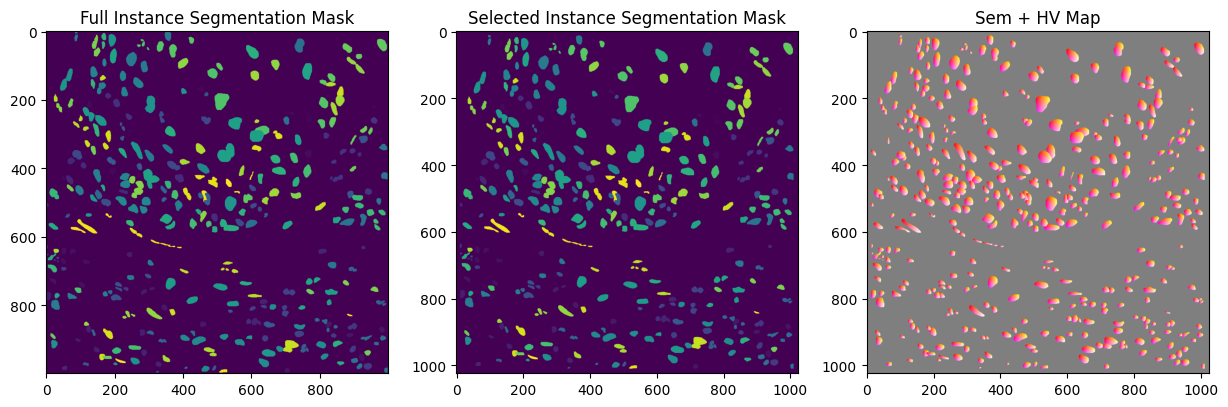

In [4]:
mask_name = os.path.splitext(os.path.basename(mask_file_path))[0]
inst = load_inst_mask_from_path(mask_file_path)
inst_padded = crop_and_pad_inst_mask(inst,crop_mask)

mask = convert_mask(inst_padded)

fig, axes = plt.subplots(1,3,figsize=(15,5))
axes[0].imshow(inst)
axes[0].set_title("Full Instance Segmentation Mask")
axes[1].imshow(inst_padded)
axes[1].set_title("Selected Instance Segmentation Mask")
axes[2].imshow((mask+1)/2)
axes[2].set_title("Sem + HV Map")
print(f"Mask Name: {mask_name}")
print(f"Instance Segmentation Mask - Shape: {inst.shape}, Type: {inst.dtype}, Max: {inst.max()}, Min: {inst.min()}")
print(f"Cropped and Padded Instance Segmentation Mask - Shape: {inst_padded.shape}, Type: {inst_padded.dtype}, Max: {inst_padded.max()}, Min: {inst_padded.min()}")
print(f"Mask with HV map - Shape: {mask.shape}, Type: {mask.dtype}, Max: {mask.max()}, Min: {mask.min()}")

### Diffusion Model Inference

#### Model Setup and Configuration

In [5]:
dist_util.setup_dist()
res = dict(
    image_size=256,
    num_classes=2,
    num_channels=256,
    num_res_blocks=2,
    num_heads=4,
    num_heads_upsample=-1,
    num_head_channels=-1,
    attention_resolutions="32,16,8",
    encoder_resolutions="",
    decoder_resolutions="32,16,8",
    channel_mult="",
    dropout=0.0,
    class_cond=True,
    use_checkpoint=False,
    use_scale_shift_norm=True,
    resblock_updown=True,
    use_fp16=False,
    use_new_attention_order=False,
    no_instance=False,
)

diffusion_default = dict(
    learn_sigma=True,
    diffusion_steps=1000,
    noise_schedule="linear",
    timestep_respacing="",
    use_kl=False,
    predict_xstart=False,
    rescale_timesteps=False,
    rescale_learned_sigmas=False,
)

res.update(diffusion_default)

if fast_generation:
    res['timestep_respacing'] = '100'
    res['use_fp16'] = True

model, diffusion = create_model_and_diffusion(**res)

32,16,8  32,16,8
[8, 16, 32] [] [8, 16, 32]


#### Load Trained Model Weight

In [6]:
# You can change the path of the .pt file to your own saved model
model_checkpoint_path = finetuned_checkpoint_path if model_type == "finetuned" else coarse_checkpoint_path
model.load_state_dict(
    dist_util.load_state_dict(model_checkpoint_path, map_location="cpu")
)
print(f"{model_type} checkpoint loaded.")

finetuned checkpoint loaded.


Then we put the mask into the diffusion model and generate the image accordingly

In [7]:
generated_images = []
model.to(device)
target_fn = diffusion.p_sample_loop

cond = torch.from_numpy(mask.copy())[None].float().to(device)

if fast_generation:
    cond = cond.half() # for fp 16
    model.convert_to_fp16() # for fp 16

if batched_generation:    
    cond_batch = cond.repeat(num_generations, 1, 1, 1)  # Shape: [num_generations, H, W, C]
    model_kwargs = {'y': cond_batch.permute(0, 3, 1, 2), 's': 1.0}
    # Single batched generation call
    with torch.no_grad():
        target = target_fn(model, model_kwargs['y'].shape, model_kwargs=model_kwargs, 
                    clip_denoised=True, device=device, progress=True)

    # Unpack the batch into individual images
    for i in range(num_generations):
        generated_images.append(target[i].detach().cpu().numpy().transpose(1, 2, 0) / 2 + 1 / 2)
else:
    model_kwargs = {'y': cond.permute(0, 3, 1, 2), 's': 1.0}
    for i in range(num_generations):
        with torch.no_grad():
            target = target_fn(model, model_kwargs['y'].shape, model_kwargs=model_kwargs, clip_denoised=True, device=device, progress=True)
        generated_images.append(target[0].detach().cpu().numpy().transpose(1,2,0)/2+1/2)



gc.collect()
torch.cuda.empty_cache()

/scratch/tahsin.rahman/conda_envs/SynthNuclei/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 100/100 [02:15<00:00,  1.35s/it]


Shape: (1024, 1024, 3), Type: float32, Max: 0.999549150466919, Min: 0.007182985544204712


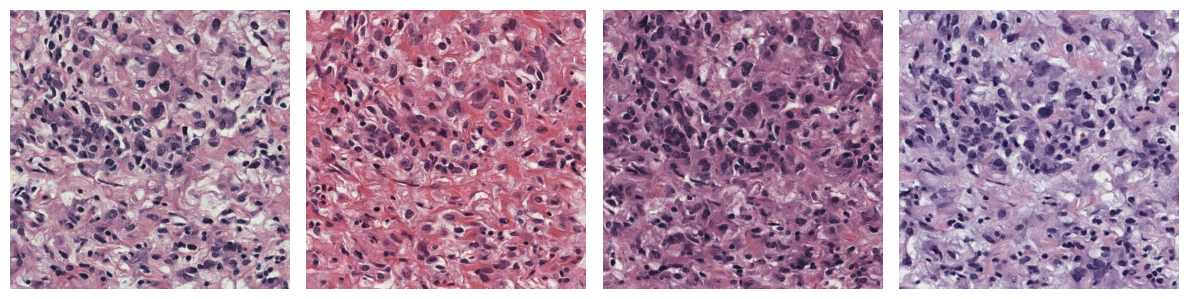

In [11]:
print(f"Shape: {generated_images[0].shape}, Type: {generated_images[0].dtype}, Max: {generated_images[0].max()}, Min: {generated_images[0].min()}")

f1 = plot_generated_images(generated_images, mask=None, figsize=(12,6))
# If the mask is provided in plot_generated_images(), the outline and overlay of the mask used to generate the images will be shown on each image

# PLot the mask for reference
# fig, ax = plt.subplots(1,1, figsize=(3,3))
# ax.imshow((mask+1)/2)
# ax.set_axis_off()
# ax.set_title("Sem + HV Map")

### Save the generated images

The image files will be named {mask_name}\_generated_image\_{i}.png

In [ ]:
save_output_uint8(generated_images, mask_name, output_path)